# Training history

<Axes: ylabel='Total loss'>

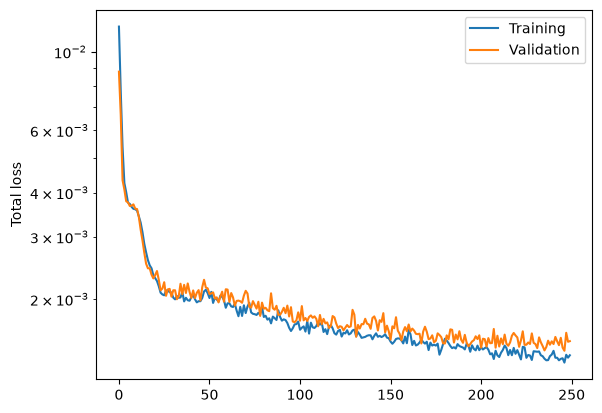

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.set(ylabel='Total loss', yscale='log')

df = pd.read_csv("vae_metrics.csv")
df.plot(y='train_loss', label='Training', ax=ax)
df.plot(y='validation_loss', label='Validation', ax=ax)

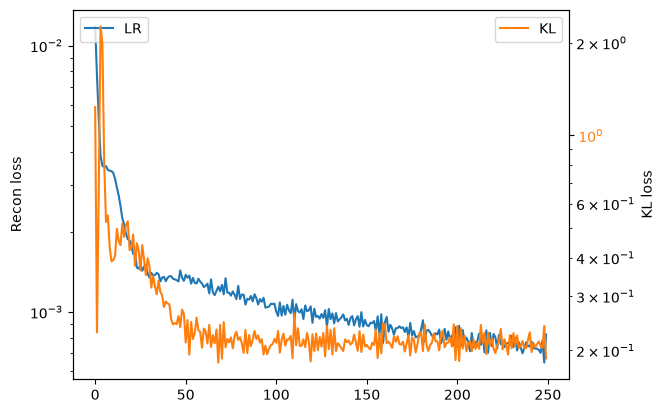

In [19]:
fig, ax = plt.subplots()
ax.set(ylabel='Recon loss', yscale='log')
df.plot(y='train_recon', label='LR', ax=ax)
ax.legend(loc=2)

ax2 = ax.twinx()
df.plot(y='train_kl', label='KL', color='tab:orange', ax=ax2)
ax2.set(ylabel='KL loss', yscale='log')
ax2.tick_params(axis='y', labelcolor='tab:orange')
ax2.legend(loc=1)

# Model loading

In [20]:
import torch
from torch.utils.data import DataLoader

from modules.model import VariationalAutoencoder
from modules.dataset import LogMinMaxScale, EnsembleDataset
from modules.generation import reconstruct_vae_samples, save_reconstructions

checkpoint = torch.load('output/vae07.pt', map_location='cpu')

## Normalization
min_value = checkpoint['MINVAL']
max_value = checkpoint['MAXVAL']
scale     = checkpoint['SCALE']
transform = LogMinMaxScale(min_value, max_value, scale)

# Model
model = VariationalAutoencoder(checkpoint['LATENT_DIM'], in_shape=checkpoint['IN_SHAPE'])
model.load_state_dict(checkpoint['model_state_dict'])

<All keys matched successfully>

# Reconstruction

In [21]:
import xarray as xr

fname = checkpoint['FNAME_VAL']
varkey = checkpoint['VARKEY']

## Loading raw data and normaliation
ds = xr.open_dataset(fname)
da = ds[varkey]

dataset = EnsembleDataset(da, transform)
loader  = DataLoader(dataset, batch_size=12,shuffle=False)

In [22]:
fname = "output/recon_vae07.nc"
reconstructions, targets = reconstruct_vae_samples(model,loader)
save_reconstructions(fname,reconstructions, targets)